# Finding paramters using new algorithm 
- Number of transitions
- Transition time
- Sync state time
- Dwell time

In [1]:
# %matplotlib widget
import pickle
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob
import statistics
import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu

In [2]:
analyse =AnalysisFunc()
reader = DataRead()
algo = UmapAlgo()
utils=DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


This umap_model.pkl file is already trained. Don't  play with it. I have saved in current notebook folder so that you can use it here. I also saved one copy in data folder

In [5]:
def compute_parameters(df): 
    """ Computes 
    1. Number of transitions
    2. Transition Time
    3. Sync State Time
    4. Dwell Time

    Args: 
        df (dataframe): dataframe column of 1xtimesteps entries
    Returns: 
        Dictionary: Keys - 'start_points','stop_points'
    """
    # load pre-trained model 
    # change pathway when you finalise
    with open('umap_model.pkl', 'rb') as f:
        _s, _u = pickle.load(f)
    
    # smooth data
    _data=df.rolling(800, center=True).mean().ffill().bfill()

    chunk_size = 400
    # When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
    chunks = [_data[i:i + chunk_size] for i in range(0, len(_data)-chunk_size, chunk_size//4)]
    # create overlapping chunks with 75% overlap
    
    # _s = StandardScaler().fit(chunks)
    scaled_data = _s.transform(chunks)
    # Train StandardScaler, Z score normalising values
    
    # _u = u.fit(scaled_data)
    embedding = _u.transform(scaled_data)
    # Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary
    
    sep = -0.6

    l_embed=[]
    for l in _data.index[:-chunk_size][::chunk_size//4][embedding[:, 0]>sep]:
        l_embed.append(l)

# Finding start stop points of transition
    start=[]
    stop=[]
    
    if len(l_embed)!=0:
        start=[l_embed[0]]
        
        ind=0
        while ind<len(l_embed)-1:
            
            if l_embed[ind+1]-l_embed[ind] >400:
                stop.append(l_embed[ind])
                start.append(l_embed[ind+1])
                
            ind+=1
            
        # for adding start point
        if len(start)!=0:
            print(f'start {start}')
            if l_embed[-1]-start[-1]<400: 
                start.pop(-1)       
        
        #for adding stop points if it falls
        if len(start)!=0:
            if l_embed[-1]-start[-1] > 400:
                stop.append(l_embed[-1])
                if len(start)!=len(stop):
                    stop.pop(-1)
        
        # Ignoring where GO never crosses 0.2 and length > 400 
        for _start,_stop in zip(start,stop):
            val=[]
            for r in range(_start,_stop,100): 
                val.append(_data[r])
                
            if _stop-_start<=400 or r<=0.2: 
                stop.remove(_stop)
                start.remove(_start)
        
        # if there is only one transition which does not fall back, remove the stop point 
        if len(stop)!=0:
            if _data[stop[-1]]>=0.3: 
                stop.pop(-1)

    points_dict=dict(zip(['start_points','stop_points'],[start,stop]))
    return points_dict
    
    

In [93]:
data = pd.read_pickle('../../data/raw/FN/itr_200.bz2')


## Making coverage to consider all transitions

In [4]:
l=analyse.compute_param(data,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [3]:
n=3

analyse.plot_global_synchrony(data[n],0.05)

NameError: name 'data' is not defined

In [63]:
h=algo.compute_parameters(data[n])

start [8700, 37200]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [64]:
h

{'start_points': [8700], 'stop_points': [33100]}

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


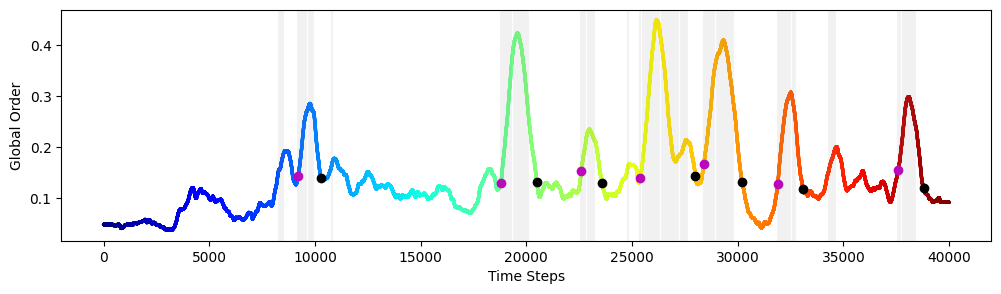

In [51]:
algo.plot_transition(data[n],h['start_points'],h['stop_points'])

In [39]:
def compute_coverage(df,start,stop):
    """ Computes average global order from 1st transition start to stop point
    Args:
        df (dataframe): Single iteration 1 x timestep
        start (list): From compute_parameters(df)
        stop (list): From compute_parameters(df)
    """
    df=df.rolling(800, center=True).mean().ffill().bfill()
    cov_int=[]
    if not start:
        cov=0
        print('case1')
    elif not stop:
        cov= df[start[0]:].mean()
        print('case2')
    elif len(start)==len(stop):
        i=0
        while i < len(start):
            cov_int.append(df[start[i]:stop[i]].mean())
            i+=1
        print(cov_int)
        cov=statistics.mean(cov_int)
        print('case3')
    else:
        i==0
        stop.append(39999)
        while i < len(start):
            cov_int.append(df[start[i]:stop[i]].mean())
            i+=1
        cov=statistics.mean(cov_int)
        print('case4')
    return cov


    

In [40]:
compute_coverage(data[n],h['start_points'],h['stop_points'])

[0.3720299252213636]
case3


0.3720299252213636

In [9]:
cvr=algo.compute_coverage(data[n],h['start_points'],h['stop_points'])
cvr

[0.38587320472479136, 0.3861456900638884, 0.3908337780374676, 0.2377974752782292]


0.3501625370260941

In [20]:
h=algo.compute_param_df(data)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7000, 36800]
37363


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6500, 11000, 23800, 36600]
7223
24531
37440


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

start [15200]
16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669


### checking coverage 

In [21]:
h['cov']

[0.24183387967431963,
 0.29804099670230744,
 0.4418069445499282,
 0.08631286895581236,
 0.302199458674971,
 0.5123072507282169,
 0.22962892370351048,
 0.5345281952637835,
 0.28740249751079283,
 0.27785046386936074,
 0.27076739124300847,
 0.4918774564963628,
 0.26985644641673323,
 0.2501757351372732,
 0.24603271199216964,
 0.21899324240779516,
 0.47419731430627976,
 0.2810394276779629,
 0.46260847968591834,
 0.21083829745731367,
 0.33711713765877643,
 0.5248870334062361,
 0.4427228994156579,
 0.28999833599406705,
 0.3041296717502477,
 0.47975036033189006,
 0.5309594652345034,
 0.45116076013196665,
 0.21334771377222764,
 0.5132704180798133,
 0.4876933791708004,
 0.4356709536612702,
 0.37731267695872894,
 0.24272390583814613,
 0.3886086309319743,
 0.22644634423197868,
 0.2533984645183807,
 0.3725843050355362,
 0.44570767086870444,
 0.2323689871177497,
 0.5182103408226546,
 0.22849563041128126,
 0.3954238945706496,
 0.5599386753136593,
 0.5351533566016595,
 0.45107513418364015,
 0.54552766

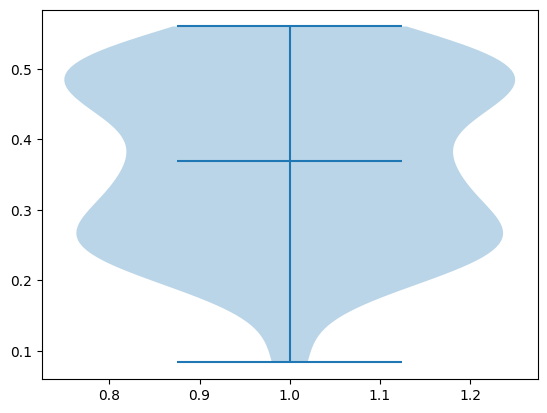

In [22]:
#cvr=[j for j in h['cov'] if j!=0 and not np.isnan(j)]
plt.violinplot(h['cov'], showmedians=True)
plt.show()

## Defining FPT which considers all transitions

In [52]:
def compute_fpt(df,start,stop):
    """Computes average FPT for a particular iteration considering all transitions
    Args:
        df (dataframe): Single iteration 1 x timestep
        start (list): From compute_parameters(df)
        stop (list): From compute_parameters(df)
    Return:
        fpt (float): Average FPT for an iteration
        """
    fpt_int=[]
    df=df.rolling(800, center=True).mean().ffill().bfill()
    if not start:
        fpt=0
    elif not stop:
        fpt=start[0]
    elif len(start) == len(stop):
        i=1
        fpt_int.append(start[0])
        while i<len(start):
            fpt_int.append(start[i]-stop[i-1])
            i+=1
        print(fpt_int)
        fpt=statistics.mean(fpt_int)
    else:
        i=1
        fpt_int.append(start[0])
        while i<len(start):
            fpt_int.append(start[i]-stop[i-1])
            i+=1
        print(fpt_int)
        fpt=statistics.mean(fpt_int)

    return fpt*0.05
    

In [53]:
compute_fpt(data,h['start_points'],h['stop_points'])

[9200, 8900, 2500, 2200, 800, 2100, 4900]


218.57142857142858

In [65]:
algo.compute_fpt(data[n],h['start_points'],h['stop_points'])

[8700]


435.0

In [107]:
data=reader.data_read_bz2('raw/FN/itr_200.bz2')

In [105]:
params=algo.compute_param_df(data)


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7000, 36800]
37363


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6500, 11000, 23800, 36600]
7223
24531
37440


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669


In [79]:
params['sync']

[70.0,
 115.0,
 222.5,
 70.0,
 117.5,
 80.0,
 87.5,
 157.5,
 93.57142857142857,
 80.0,
 65.0,
 90.0,
 1260.0,
 67.5,
 75.0,
 96.66666666666667,
 130.0,
 95.0,
 1705.0,
 179.0,
 65.0,
 116.66666666666669,
 165.0,
 220.0,
 70.0,
 70.0,
 65.0,
 80.0,
 278.0,
 55.0,
 70.0,
 110.83333333333333,
 58.33333333333334,
 231.66666666666666,
 827.5,
 547.5,
 177.5,
 407.5,
 215.0,
 55.0,
 70.0,
 80.0,
 70.0,
 65.0,
 82.5,
 257.5,
 65.0,
 139.0,
 600.0,
 132.5,
 665.0,
 112.5,
 467.5,
 376.25,
 181.25,
 255.0,
 71.66666666666667,
 118.33333333333333,
 135.0,
 200.0,
 392.5,
 85.0,
 65.0,
 72.5,
 95.71428571428572,
 92.5,
 370.0,
 1110.0,
 293.75,
 65.0,
 100.0,
 73.33333333333334,
 146.66666666666669,
 113.0,
 65.0,
 101.66666666666667,
 259.0,
 296.25,
 50.0,
 281.6666666666667]

{'bodies': [<matplotlib.collections.PolyCollection at 0x71cb3a1bc550>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x71cb1f3b1e70>,
 'cmins': <matplotlib.collections.LineCollection at 0x71cb25b901c0>,
 'cbars': <matplotlib.collections.LineCollection at 0x71cb25b913f0>,
 'cmedians': <matplotlib.collections.LineCollection at 0x71cb25b91de0>}

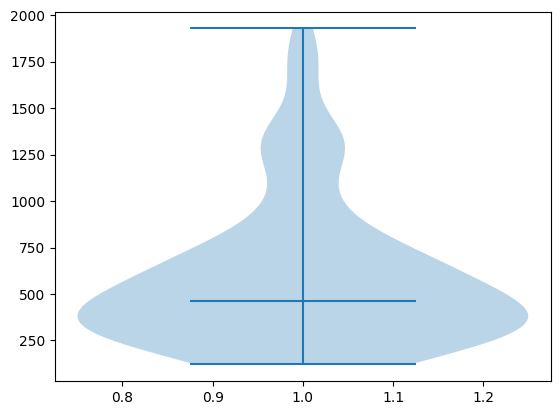

In [61]:
plt.violinplot(params['fpt'],showmedians=True)

## Finding partial and full transitions on basis of coverage

### For threshold coverage, let's plt all coverages and not meanabs

In [97]:
def compute_coverage(df,start,stop):
    """ Computes average global order from 1st transition start to stop point
    Args:
        df (dataframe): Single iteration 1 x timestep
        start (list): From compute_parameters(df)
        stop (list): From compute_parameters(df)
    """
    df=df.rolling(800, center=True).mean().ffill().bfill()
    cov_int=[]
    if not start:
        cov=0
        cov_int.append(cov)
        print('case1')
    elif not stop:
        cov= df[start[0]:].mean()
        cov_int.append(cov)
        print('case2')
    elif len(start)==len(stop):
        i=0
        while i < len(start):
            cov_int.append(df[start[i]:stop[i]].mean())
            i+=1
        #print(cov_int)
        
        print('case3')
    else:
        i=0
        stop.append(39999)
        while i < len(start):
            cov_int.append(df[start[i]:stop[i]].mean())
            i+=1
        
        print('case4')
    return cov_int

In [108]:
c=0
cov=[]
while c<data.shape[1]:
    l=algo.compute_parameters(data[c])
    cvr=compute_coverage(data[c],l['start_points'],l['stop_points'])
    for i in cvr:
        cov.append(i)
    c+=1

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [7000, 36800]
case3
case1


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6500, 11000, 23800, 36600]
case3
start [12800]
case2


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

...

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [15200]
case2
start [6400, 11700, 14100]
case4


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

case1
start [10000, 15500, 35600]
case3


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


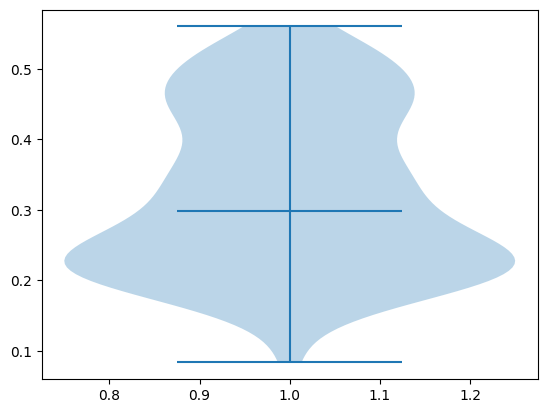

In [109]:
coverage=[j for j in cov if j!=0 and not np.isnan(j)]
plt.violinplot(coverage,showmedians=True);

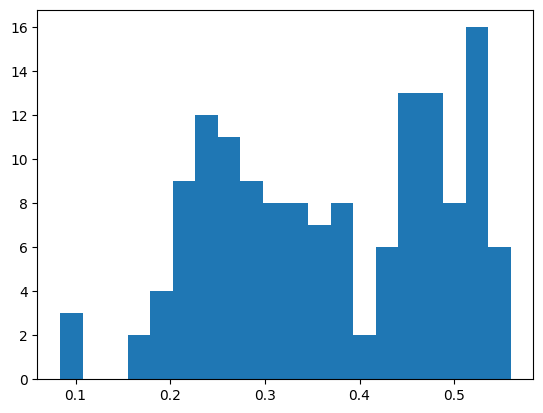

In [88]:
plt.hist(params['cov'], bins=20);

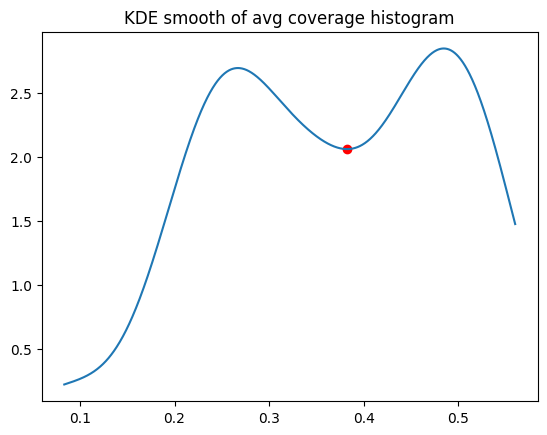

Estimated minima at: [0.38205335]


In [106]:
data = params['cov']
kde = gaussian_kde(data)
x = np.linspace(min(data), max(data), 1000)
y = kde(x)

# Find local minima
dy = np.gradient(y)
minima_indices = np.where(np.diff(np.sign(dy)) > 0)[0]
minima_x = x[minima_indices]

plt.plot(x, y)
plt.scatter(minima_x, y[minima_indices], color='red')
plt.title('KDE smooth of avg coverage histogram')
plt.show()

print("Estimated minima at:", minima_x)


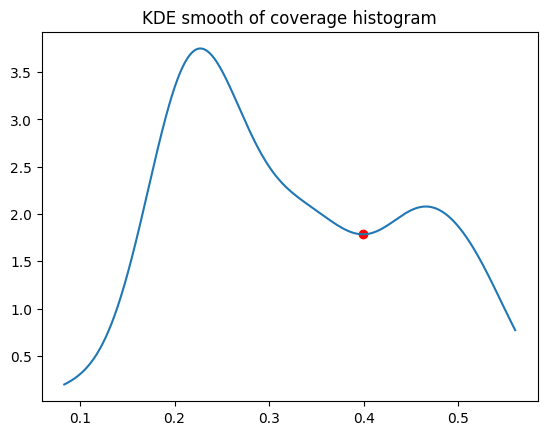

Estimated minima at: [0.39874501]


In [111]:
data = coverage
kde = gaussian_kde(data)
x = np.linspace(min(data), max(data), 1000)
y = kde(x)

# Find local minima
dy = np.gradient(y)
minima_indices = np.where(np.diff(np.sign(dy)) > 0)[0]
minima_x = x[minima_indices]

plt.plot(x, y)
plt.scatter(minima_x, y[minima_indices], color='red')
plt.title('KDE smooth of coverage histogram')
plt.show()

print("Estimated minima at:", minima_x)


In [ ]:
al

In [6]:
params.keys()

dict_keys(['tran_per', 'sync', 'trans', 'fpt'])

In [7]:
params['tran_per']

[1, 135, 299]

In [5]:
data.shape

(40000, 200)

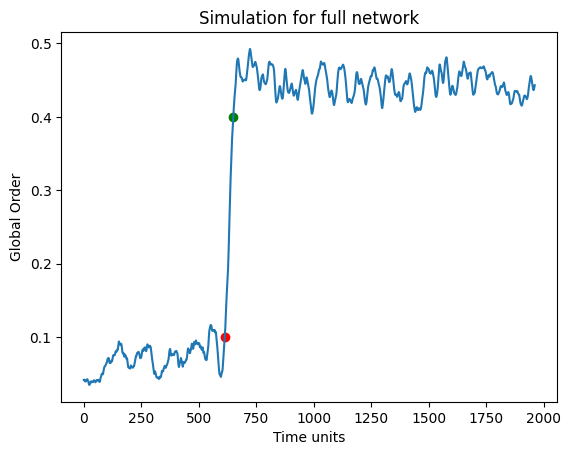

In [21]:
analyse.plot_global_synchrony(data[3],0.05)


In [6]:
run=3
l=compute_parameters(data[run])

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [12800]


In [23]:
l['start_points'][0]*0.05

640.0

In [24]:
l

{'start_points': [12800], 'stop_points': []}

In [25]:
data.columns=list(range(0,data.shape[1]))
k=analyse.compute_param(data,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [26]:
def plot_transition(df,start,stop,chunk_size=400):
    """Plots the global order data and mark starting and ending of all transitions
    Args:
        df (dataframe): global synchrony order (1 x timestep)
        start, stop : Points from compute_parameters(df) function
        chunk_size  : By default it is 400

    Returns:
        None
        """
    _data=df.rolling(800, center=True).mean().ffill().bfill()
    fig,ax=plt.subplots(figsize=(12,3))
    cmap='jet'
    with open('umap_model.pkl', 'rb') as f:
        _s, _u = pickle.load(f) 
    chunk_size = 400
    # When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
    chunks = [_data[i:i + chunk_size] for i in range(0, len(_data)-chunk_size, chunk_size//4)]
    # create overlapping chunks with 75% overlap
    
    # _s = StandardScaler().fit(chunks)
    scaled_data = _s.transform(chunks)
    # Train StandardScaler, Z score normalising values
    
    # _u = u.fit(scaled_data)
    embedding = _u.transform(scaled_data)
    # Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary
    
    sep = -0.6
    ax.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
    for i in stop:
        ax.plot(i+chunk_size,_data[i+chunk_size],'ko')
    for i in start: 
        ax.plot(i,_data[i],'mo')
    for l in _data.index[:-chunk_size][::chunk_size//4][embedding[:, 0]>sep]:
        ax.axvline(l, c='gray', alpha=0.1)
    ax.set_ylabel('Global Order')
    ax.set_xlabel('Time Steps')

In [27]:
data.shape

(40000, 200)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


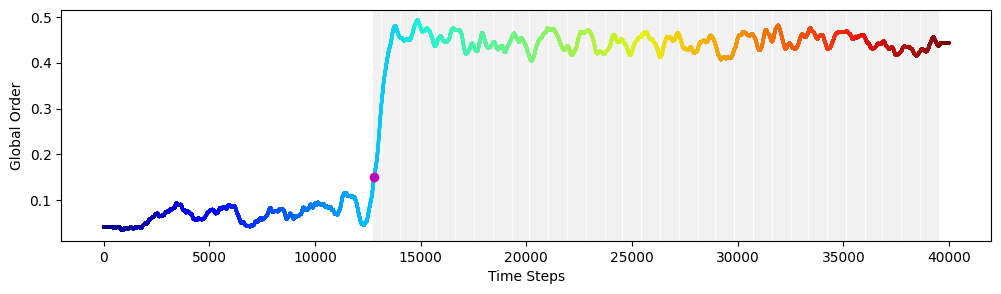

In [28]:
plot_transition(data[run],l['start_points'],l['stop_points'])

## Compute coverage
- Taken average of global order from start to stop pint of transition
- If no fall back, taken average global order through out

In [32]:
def compute_coverage(df,start,stop):
    """ Computes average global order from 1st transition start to stop point
    Args:
        df (dataframe): Single iteration 1 x timestep
        start (list): From compute_parameters(df)
        stop (list): From compute_parameters(df)
    """
    if not stop:
        print(df[start[0]:].mean())
    else:
        print(df[start[0]:stop[0]].mean())
    # though median gives much better value

Let's check on single transition run

In [33]:
compute_coverage (data[run],l['start_points'],l['stop_points'])

0.4422860130698315


In [7]:
algo.compute_coverage(data[run],l['start_points'],l['stop_points'])

0.4422860130698315


In [13]:
print(data[run][l['start_points'][0]])
print(data[run][l['stop_points'][0]])

0.07627072821490177
0.34398195522248687


In [14]:
data[run][l['stop_points'][0]] - data[run][l['start_points'][0]]

0.2677112270075851

# For whole dataframe

### Compute sync state time


In [26]:
def compute_sync(start,stop): 
    """Calculate sync state time by caculating average  time the network was in synchronised state
    Args:
        start, stop : Take from compute_parameters(df)
    Returns:
        Float : Sync state time"""
    t=[]
    st=0
    chunk_size=400
    if len(start)!=0 and len(stop)!=0:
        if len(start)==len(stop) or len(start)>len(stop):
            for _start,_stop in zip(start,stop):
                time = _stop+chunk_size-(_start-chunk_size)
                t.append(time)
        # print(t)
        st=(sum(t)/len(t))*0.05
    return st

In [27]:
s_time=compute_sync(l['start_points'],l['stop_points'])
s_time


[3300, 1400]


117.5

### Compute transition time


In [3]:
def compute_transition_time(df,start): 
    """Compute transition time given the start time 
    Args:
        df (dataframe): single iteration 1 x timestep
        start (list): From compute_parameters(df)
    Returns:
        list: Containing transition time for every transition
    
    """
    window_size = 200
    _data=df.rolling(800, center=True).mean().ffill().bfill()
    # Define a function to calculate slope for a given window
    def calculate_slope(window):
        if len(window) < 2:  # Need at least two points to calculate slope
            return np.nan
        x = np.arange(0,len(window),1)
        y = window.values
        # Using numpy.polyfit for linear regression to get slope
        slope, intercept = np.polyfit(x, y, 1)
        return slope
    
    # Apply the slope calculation over a rolling window
    #rolling_slopes = _data[l_embed].rolling(window=window_size).apply(calculate_slope, raw=False)
    t_time=[]
    for k in start:
        rolling_slopes = _data[k:].rolling(window=window_size).apply(calculate_slope, raw=False)
        for i in rolling_slopes.index:
            if rolling_slopes[i] <0:
                print(i)
                c=i-1
                t_time.append(c)
                break

    
    t=[]
    if len(start)>0:
        for _init,_end in zip(start,t_time):
            time=_end-(_init-400)
            t.append(time)
    
    transition_time=[item*0.05 for item in t]
    
    return transition_time 

### Checking above function

In [74]:
compute_transition_time(data[39],[16000])

17488


[94.35000000000001]

In [84]:
c=0
trans_count=0
s_time=[]
t_time=[]
while c<200: 
    l=compute_parameters(data[c])
    
    # trans_count=trans_count+len(l['start_points'])
    # s_time.append(compute_sync(l['start_points'],l['stop_points']))
    tran_time=compute_transition_time(data[c],l['start_points'])
    for item in tran_time: 
        t_time.append(item)
    
    c+=1
print(t_time)


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7000, 36800]
37363


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6500, 11000, 23800, 36600]
7223
24531
37440


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669
[48.1, 56.1, 56.5, 61.95, 74.45, 56.050000000000004, 73.60000000000001, 65.85000000000001, 62.7, 43.650000000000006, 74.7, 45.150000000000006, 91.15, 63.1, 50.900000000000006, 53.050000000000004, 53.650000000000006, 59.5, 73.60000000000001, 55.150000000000006, 84.60000000000001, 60.550000000000004, 53.6, 61.300000000000004, 37.65, 63.85, 55.550000000000004, 51.95, 57.6, 50.050000000000004, 57.900000000000006, 45.550000000000004, 50.95, 116.15, 57.2, 66.5, 44.95, 55.5, 49.0, 72.05, 89.7, 89.0, 47.1, 59.5, 65.25, 58.150000000000006, 64.4, 73.75, 84.5, 55.900000000000006, 35.7, 45.0, 44.1, 48.650000000000006, 49.7, 44.550000000000004, 94.35000000000001, 69.55, 66.65, 69.35000000000001, 47.35, 40.300000000000004, 40.35, 92.55000000000001, 45.0, 94.35000000000001, 43.400000000000006, 50.0, 69.5, 48.300000000000004, 75.4, 66.45, 87.85000000000001, 50.6, 81.75, 49.150000000000006, 51.7, 65.60000000000001, 88.5, 86.55000000000001, 72.45, 82.3000000

## compute for any dataframe (set of 200 iterations)

In [30]:
def compute_param_df(data):
    """To compute all parameters for a set of transitions
    Args:
        data (dataframe): Global order data (timesteps x no. of iterations)
    Returns:
        dictionary: Keys: 'tran_per','sync','trans','fpt'
        """
    c=0
    trans_count=0
    tran_per=[] # to store number of transitions per 100 iterations
    s_time=[]
    fpt=[]
    tran_time=[]
    while c<data.shape[1]: 
        l=compute_parameters(data[c])  # Calculate start and stop points
        
        trans_count=trans_count+len(l['start_points'])
        if c%100==0 or c==data.shape[1]-1:
            tran_per.append(trans_count)

        s_time.append(compute_sync(l['start_points'],l['stop_points']))
        if len(l['start_points'])!=0:
            fpt.append(l['start_points'][0]*0.05)

        t_time=compute_transition_time(data[c],l['start_points'])
        for item in t_time:
            tran_time.append(item)
            
        c+=1

    param_dict=dict(zip(['tran_per','sync','trans','fpt'],[tran_per,s_time,tran_time,fpt]))
    return param_dict

### Checking above for data (set of 200 iterations)


In [4]:
h=algo.compute_param_df(data)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7000, 36800]
37363


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UnboundLocalError: local variable 'cov' referenced before assignment

In [32]:
len(h['trans'])
h['tran_per']
len(h['fpt'])

147

In [5]:
h['cov']

NameError: name 'h' is not defined

{'bodies': [<matplotlib.collections.PolyCollection at 0x75c37c9e25c0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x75c37c9e3670>,
 'cmins': <matplotlib.collections.LineCollection at 0x75c37c9e1480>,
 'cbars': <matplotlib.collections.LineCollection at 0x75c37c9e2410>,
 'cmedians': <matplotlib.collections.LineCollection at 0x75c37c9e16f0>}

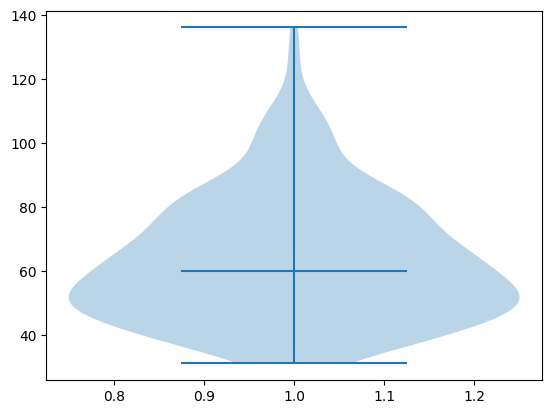

In [91]:
plt.violinplot(h['trans'],showmedians=True)

## Applyin above function over data for NOI

- On data for which we have 1000 iterations


In [ ]:
data_folder = Path("../../data/results/processed/")
files=glob.glob(str(data_folder/"itr*.bz2"))

tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states
fpt_params={}
cvr_params={}
t_time=[]
for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")
    df_d.columns=range(0,df_d.shape[1]) 

    # Compute parameters
    params = algo.compute_param_df(df_d)
    
    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params['trans']
    # removing those which have sync state time zero
    sync=[i for i in params['sync'] if i!=0]
    sync_params[f"{name_suffix}"] = sync
    fpt_params[f"{name_suffix}"] = params["fpt"]
    cvr=[j for j in params['cov'] if j!=0 and not np.isnan(j)]
    cvr_params[f"{name_suffix}"] = cvr
    print(f'{f} DONE')


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [34800]
35125


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [9500, 15500, 19500, 26900]
[1500]
16135


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

...

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [12400]
14162
start [19900]
[1300]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


20478


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [101]:
params['trans']


[78.30000000000001,
 44.150000000000006,
 69.25,
 50.25,
 67.75,
 68.25,
 86.5,
 70.65,
 113.4,
 62.1,
 98.30000000000001,
 93.55000000000001,
 37.85,
 37.550000000000004,
 57.25,
 44.150000000000006,
 82.35000000000001,
 49.550000000000004,
 68.3,
 44.35,
 36.85,
 49.7,
 53.6,
 51.550000000000004,
 68.15,
 32.35,
 40.050000000000004,
 67.4,
 62.400000000000006,
 50.400000000000006,
 37.35,
 29.900000000000002,
 57.400000000000006,
 62.95,
 62.5,
 62.1,
 39.75,
 50.900000000000006,
 37.4,
 36.550000000000004,
 45.75,
 57.400000000000006,
 49.650000000000006,
 50.400000000000006,
 68.3,
 57.35,
 53.800000000000004,
 74.3,
 57.300000000000004,
 63.45,
 63.6,
 72.0,
 73.15,
 50.150000000000006,
 83.75,
 71.7,
 80.80000000000001,
 64.2,
 60.550000000000004,
 64.9,
 86.15,
 55.2,
 63.550000000000004,
 79.65,
 78.85000000000001,
 61.650000000000006,
 86.55000000000001,
 46.35,
 48.550000000000004,
 79.75,
 75.9,
 84.55000000000001,
 54.45,
 55.0,
 68.7,
 75.2,
 43.5,
 33.75,
 41.050000000000

In [47]:
sync_params

{'bla': [0,
  0,
  0,
  55.0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  590.0,
  0,
  0,
  0,
  0,
  46.66666666666667,
  0,
  0,
  0,
  0,
  250.0,
  0,
  60.0,
  0,
  0,
  205.0,
  118.75,
  270.0,
  0,
  55.0,
  0,
  0,
  0,
  0,
  0,
  0,
  45.0,
  45.0,
  0,
  0,
  0,
  0,
  242.5,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  75.0,
  0,
  112.5,
  80.0,
  0,
  52.5,
  55.0,
  61.0,
  0,
  0,
  82.5,
  0,
  0,
  0,
  0,
  0,
  0,
  625.0,
  0,
  0,
  0,
  75.0,
  85.0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  75.0,
  0,
  0,
  0,
  0,
  35.0,
  0,
  45.0,
  852.5,
  0,
  112.5,
  50.0,
  0,
  0,
  0,
  92.5,
  0,
  0,
  0,
  222.5,
  0,
  260.0,
  0,
  0,
  0,
  0,
  88.33333333333334,
  0,
  0,
  167.5,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  50.0,
  0,
  0,
  0,
  0,
  100.0,
  0,
  0,
  0,
  310.0,
  0,
  45.0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  161

In [48]:
trans_params

{'bla': [1740.0,
  775.0,
  500.0,
  435.0,
  1350.0,
  1365.0,
  1405.0,
  315.0,
  595.0,
  315.0,
  890.0,
  540.0,
  1230.0,
  775.0,
  785.0,
  945.0,
  620.0,
  940.0,
  1030.0,
  1200.0,
  780.0,
  775.0,
  1610.0,
  1130.0,
  1485.0,
  495.0,
  810.0,
  315.0,
  990.0,
  330.0,
  905.0,
  505.0,
  565.0,
  830.0,
  1160.0,
  850.0,
  425.0,
  1720.0,
  1305.0,
  1090.0,
  930.0,
  1175.0,
  1770.0,
  475.0,
  1400.0,
  1665.0,
  255.0,
  415.0,
  660.0,
  930.0,
  710.0,
  590.0,
  1405.0,
  960.0,
  735.0,
  355.0,
  715.0,
  705.0,
  775.0,
  345.0,
  805.0,
  455.0,
  1435.0,
  220.0,
  560.0,
  1815.0,
  345.0,
  1310.0,
  1000.0,
  840.0,
  605.0,
  455.0,
  735.0,
  1935.0,
  715.0,
  985.0,
  335.0,
  385.0,
  600.0,
  405.0,
  705.0,
  1010.0,
  505.0,
  365.0,
  460.0,
  1420.0,
  470.0,
  495.0,
  1015.0,
  1430.0,
  395.0,
  515.0,
  1485.0,
  1320.0,
  650.0,
  445.0,
  1300.0,
  305.0,
  680.0,
  220.0,
  1570.0,
  420.0,
  305.0,
  1070.0,
  480.0,
  1180.0,
  475

In [119]:
reader.data_dump_pkl('tran_100.pkl',tranPer_params)

### Remove zero entries from Sync State


In [111]:
for k in node_order[non]:
    l=[]
    for i in sync_params[k]: 
        
        if i!=0: 
            l.append(i)
        
    sync_params[k]=l
   



In [4]:

# removing all zero entries
reader.data_dump_pkl('sync_state.pkl',sync_params)

NameError: name 'sync_params' is not defined

In [121]:
reader.data_dump_pkl('trans_time.pkl',trans_params)

In [122]:
reader.data_dump_pkl('fpt.pkl',fpt_params)

In [22]:
sync_params=reader.data_read_pkl('sync_state.pkl')
trans_params=reader.data_read_pkl('trans_time.pkl')
tranPer_params=reader.data_read_pkl('tran_100.pkl')
fpt_params = reader.data_read_pkl('fpt.pkl')



In [14]:
tranPer_params

{'bla': [1, 81, 143, 214, 284, 346, 401, 480, 556, 637, 686],
 'enti': [1, 109, 202, 328, 462, 553, 659, 792, 895, 995, 1124],
 'fn': [1, 133, 273, 405, 521, 632, 744, 919, 1033, 1151, 1279],
 'orbi': [1, 121, 263, 371, 468, 599, 727, 824, 961, 1076, 1217],
 'peri': [0, 63, 146, 225, 301, 402, 477, 533, 618, 687, 782],
 'pir': [7, 98, 193, 283, 393, 503, 582, 682, 790, 897, 979],
 're': [1, 155, 294, 454, 614, 752, 903, 1047, 1196, 1334, 1471]}

In [5]:
for key,value in tranPer_params.items(): 
    dum=np.array(value)
    value=list(np.diff(dum))
    tranPer_params[key]=value

print(tranPer_params)
    

{'bla': [80, 62, 71, 70, 62, 55, 79, 76, 81, 49], 'enti': [108, 93, 126, 134, 91, 106, 133, 103, 100, 129], 'fn': [132, 140, 132, 116, 111, 112, 175, 114, 118, 128], 'orbi': [120, 142, 108, 97, 131, 128, 97, 137, 115, 141], 'peri': [63, 83, 79, 76, 101, 75, 56, 85, 69, 95], 'pir': [91, 95, 90, 110, 110, 79, 100, 108, 107, 82], 're': [154, 139, 160, 160, 138, 151, 144, 149, 138, 137]}


In [15]:
node_order=np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non

array([1, 4, 5, 2, 3, 6, 0])

In [16]:
list(fpt_params.keys())


['bla', 'enti', 'fn', 'orbi', 'peri', 'pir', 're']

## Plot of all parameters for the new data

NOTE: 
Run ManWHitney test cells below so that you don't get error here




## Man whitne U test to find if there is sinificant shift in median position



In [17]:



# simulate two distributions

sync_node=[]
group1 = np.asarray(sync_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(sync_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p<0.05: 
        sync_node.append(k)
    print(f" Sync state: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f'Significant node: {sync_node}')
    




    

 Sync state: bla Mann–Whitney U = 38006.0, p = 0.992
 Sync state: peri Mann–Whitney U = 43587.0, p = 0.206
 Sync state: pir Mann–Whitney U = 47010.5, p = 0.829
 Sync state: enti Mann–Whitney U = 56574.5, p = 0.728
 Sync state: orbi Mann–Whitney U = 55035.5, p = 0.927
 Sync state: re Mann–Whitney U = 66700.0, p = 0.712
 Sync state: fn Mann–Whitney U = 57122.0, p = 1.000
Significant node: []


In [18]:
trans_node=[]
group1 = np.asarray(trans_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(trans_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p<0.05:
        trans_node.append(k)
    print(f" Duration: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f'Significant node: {trans_node}')




 Duration: bla Mann–Whitney U = 408813.5, p = 0.027
 Duration: peri Mann–Whitney U = 528219.0, p = 0.019
 Duration: pir Mann–Whitney U = 634659.5, p = 0.434
 Duration: enti Mann–Whitney U = 797628.0, p = 0.000
 Duration: orbi Mann–Whitney U = 785391.5, p = 0.475
 Duration: re Mann–Whitney U = 991569.5, p = 0.005
 Duration: fn Mann–Whitney U = 814088.0, p = 1.000
Significant node: ['bla', 'peri', 'enti', 're']


In [19]:
tranPer_node=[]
group1 = np.asarray(tranPer_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(tranPer_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided',method='exact')
    if p<0.05: 
        
        
        tranPer_node.append(k)
    print(f" #transition: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")
print(f"Significant node: {tranPer_node}")



 #transition: bla Mann–Whitney U = 85.5, p = 0.116
 #transition: peri Mann–Whitney U = 83.0, p = 0.151
 #transition: pir Mann–Whitney U = 74.0, p = 0.401
 #transition: enti Mann–Whitney U = 68.5, p = 0.652
 #transition: orbi Mann–Whitney U = 65.5, p = 0.797
 #transition: re Mann–Whitney U = 51.5, p = 0.606
 #transition: fn Mann–Whitney U = 60.5, p = 1.000
Significant node: []


In [20]:
fpt_node=[]
group1 = np.asarray(fpt_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(fpt_params[k])
    
    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative='two-sided')
    if p<0.05: 
        fpt_node.append(k)
    print(f" FPT: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f'Significant node: {fpt_node}')


 FPT: bla Mann–Whitney U = 120613.5, p = 0.000
 FPT: peri Mann–Whitney U = 124427.5, p = 0.000
 FPT: pir Mann–Whitney U = 168573.5, p = 0.000
 FPT: enti Mann–Whitney U = 163811.0, p = 0.000
 FPT: orbi Mann–Whitney U = 229082.0, p = 0.581
 FPT: re Mann–Whitney U = 252453.0, p = 0.453
 FPT: fn Mann–Whitney U = 245000.0, p = 1.000
Significant node: ['bla', 'peri', 'pir', 'enti']


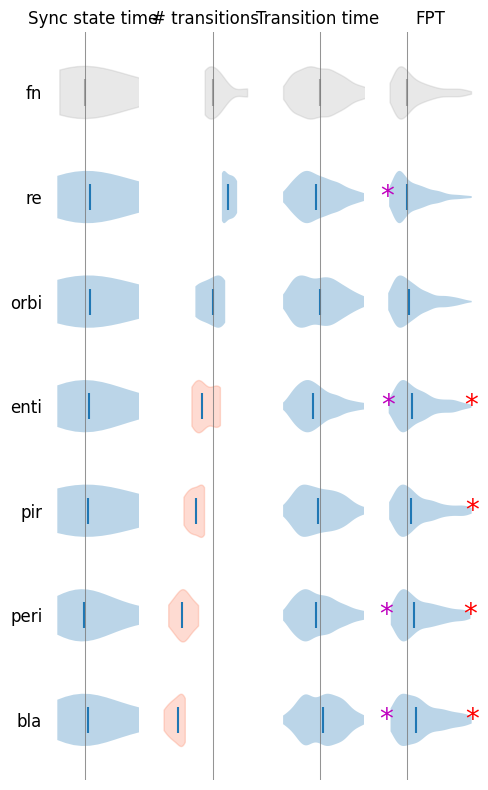

In [21]:

f,(ax1,ax2,ax3,ax4)= plt.subplots(1,4, figsize=(5,8), sharey=True)

# First passage time
_artists = ax4.violinplot(
    [fpt_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    
    showmedians=True
)
#ax4.set_yticks(np.arange(1, len(fpt_node) + 1))
#ax4.set_yticklabels(['*']*len(fpt_node), fontsize=30)

_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax4.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax4.set_xticks([])
#ax3.set_xlim(20, 100)
ax4.tick_params(axis="both", which="both", length=0)
ax4.set_title("FPT")
ax4.axvline(np.median(fpt_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


offset = 0.3   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in fpt_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(fpt_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=20)




# # number of transitions
_artists = ax3.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True
)
# ax3.set_yticks(np.arange(1, len(node_order) + 1))
# ax3.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax3.set_xticks([])
ax3.set_xlim(20, 100)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("Transition time")
ax3.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.05   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in trans_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(trans_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='m',
                 fontsize=20)



# sync state
_artists = ax1.violinplot(
    [sync_params[k] for k in node_order[non] ],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 200)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("Sync state time")
ax1.axvline(np.median(sync_params['fn']), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.1   # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in sync_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(sync_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=20)


# number of transitions
_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.01  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in tranPer_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(tranPer_params[node]) + offset
        y = idx
        ax4.text(x, y, '*',
                 ha='center',
                 va='center',
                 color='red',
                 fontsize=20)

f.subplots_adjust(wspace=0.8)
f.tight_layout()
f.savefig('sign_comp.png')






### Let's define confidence interval


In [38]:

def bootstrap_median_diff(x, y, B=5000):
    obs_diff = np.median(x) - np.median(y)
    N1, N2 = len(x), len(y)
    boot_diffs = np.empty(B)
    
    for i in range(B):
        x_star = np.random.choice(x, size=N1, replace=True)
        y_star = np.random.choice(y, size=N2, replace=True)
        boot_diffs[i] = np.median(x_star) - np.median(y_star)
    
    # two-sided p-value
    p_value = (np.sum(np.abs(boot_diffs) >= abs(obs_diff)) + 1) / (B + 1)
    # 95% CI
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
    return obs_diff, (ci_lower, ci_upper), p_value

group1 = np.asarray(fpt_params['fn'])
for k in node_order[non]:
    group2 = np.asarray(fpt_params[k])
    obs, ci, p_boot = bootstrap_median_diff(group1, group2, B=10000)
    print(f" FPT: {k} Median diff = {obs:.2f}, 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}], p = {p_boot:.3f}")
    

 FPT: bla Median diff = -202.50, 95% CI = [-247.50, -135.00], p = 0.429
 FPT: peri Median diff = -150.00, 95% CI = [-200.00, -75.00], p = 0.444
 FPT: pir Median diff = -90.00, 95% CI = [-140.00, -40.00], p = 0.476
 FPT: enti Median diff = -100.00, 95% CI = [-155.00, -42.50], p = 0.482
 FPT: orbi Median diff = -37.50, 95% CI = [-85.00, 17.50], p = 0.454
 FPT: re Median diff = 5.00, 95% CI = [-47.50, 60.00], p = 0.894
 FPT: fn Median diff = 0.00, 95% CI = [-45.00, 42.50], p = 1.000
